<a href="https://colab.research.google.com/github/oerv13-gh/Ibero/blob/main/Redes_Neu_C2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

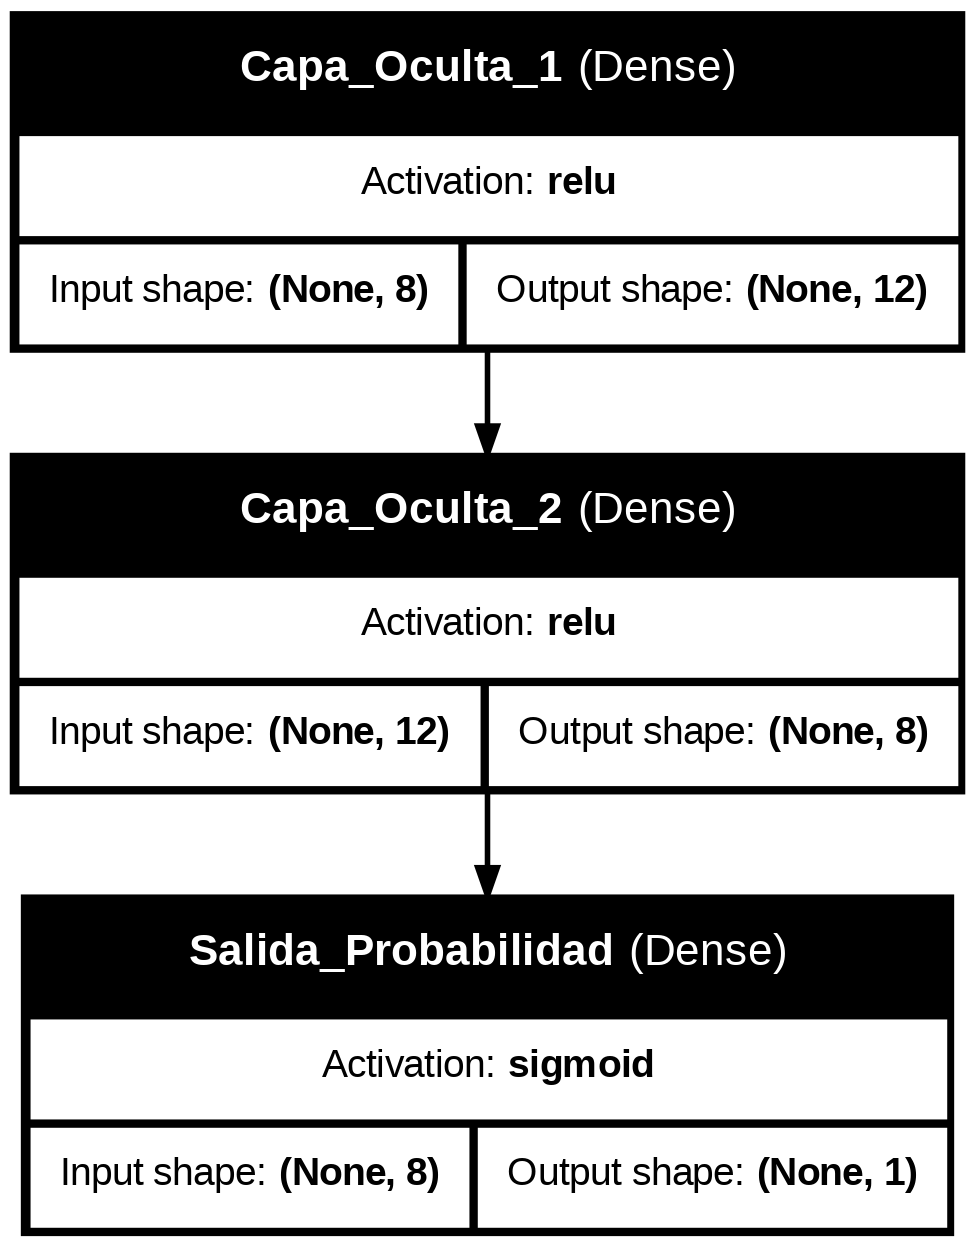

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import plot_model

# 1. Definimos la red (Usando InputLayer para que no haya errores de forma)
model = models.Sequential([
    layers.Input(shape=(8,), name="Entrada_Datos"),
    layers.Dense(12, activation='relu', name="Capa_Oculta_1"),
    layers.Dense(8, activation='relu', name="Capa_Oculta_2"),
    layers.Dense(1, activation='sigmoid', name="Salida_Probabilidad")
], name="Red_Feedforward")

# 2. Generamos el gráfico
# show_shapes=True es vital para que los alumnos vean cómo cambian los datos
plot_model(model,
           to_file='red_neuronal.png',
           show_shapes=True,
           show_layer_names=True,
           show_layer_activations=True)


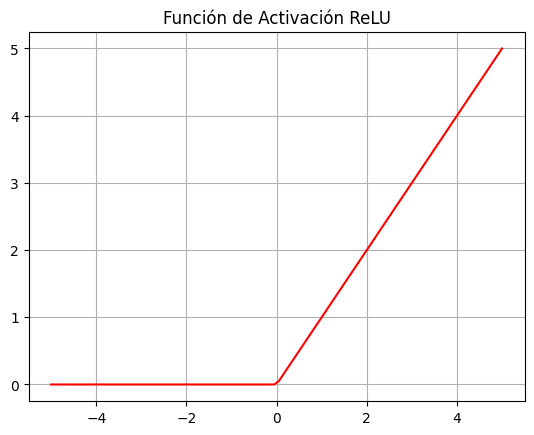

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def relu(x):
    return np.maximum(0, x)

x = np.linspace(-5, 5, 100)
plt.plot(x, relu(x), label='ReLU', color='red')
plt.title("Función de Activación ReLU")
plt.grid(True)
plt.show()

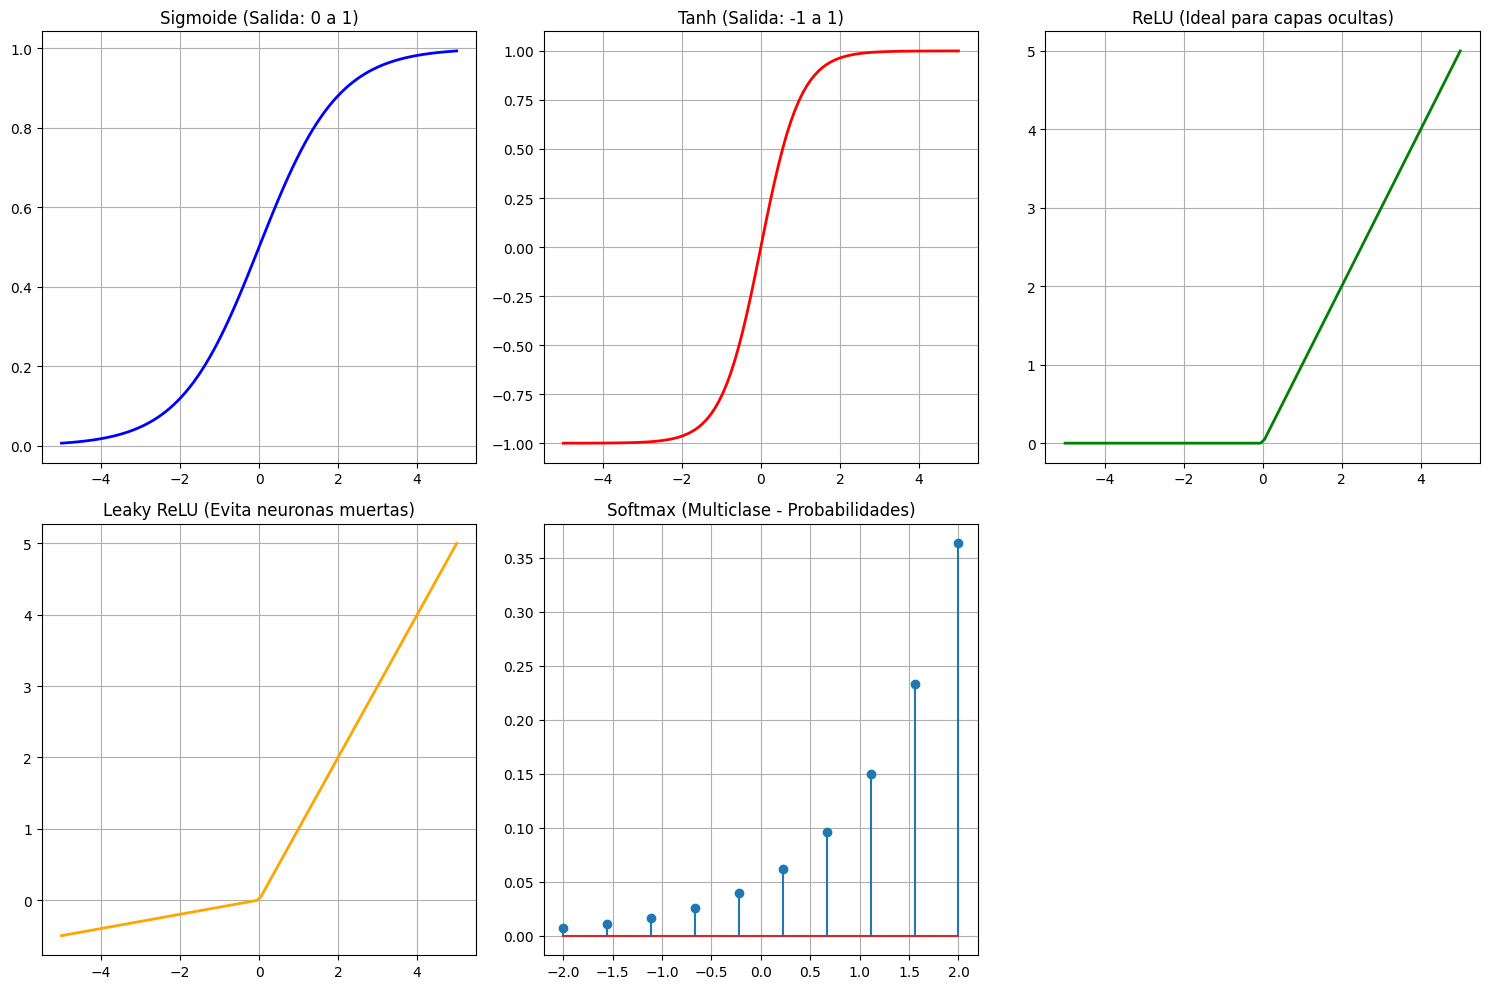

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Definición de las funciones
def sigmoid(x): return 1 / (1 + np.exp(-x))
def relu(x): return np.maximum(0, x)
def leaky_relu(x, alpha=0.1): return np.where(x > 0, x, x * alpha)
def tanh(x): return np.tanh(x)
def softmax(x): return np.exp(x) / np.sum(np.exp(x)) # Para una sola neurona es especial

x = np.linspace(-5, 5, 100)

# Configuración de la gráfica
plt.figure(figsize=(15, 10))

# 1. Sigmoide
plt.subplot(2, 3, 1)
plt.plot(x, sigmoid(x), 'b', lw=2)
plt.title('Sigmoide (Salida: 0 a 1)')
plt.grid(True)

# 2. Tanh
plt.subplot(2, 3, 2)
plt.plot(x, tanh(x), 'r', lw=2)
plt.title('Tanh (Salida: -1 a 1)')
plt.grid(True)

# 3. ReLU
plt.subplot(2, 3, 3)
plt.plot(x, relu(x), 'g', lw=2)
plt.title('ReLU (Ideal para capas ocultas)')
plt.grid(True)

# 4. Leaky ReLU
plt.subplot(2, 3, 4)
plt.plot(x, leaky_relu(x), 'orange', lw=2)
plt.title('Leaky ReLU (Evita neuronas muertas)')
plt.grid(True)

# 5. Softmax (representación conceptual)
plt.subplot(2, 3, 5)
x_soft = np.linspace(-2, 2, 10)
plt.stem(x_soft, np.exp(x_soft)/sum(np.exp(x_soft)))
plt.title('Softmax (Multiclase - Probabilidades)')
plt.grid(True)

plt.tight_layout()
plt.show()


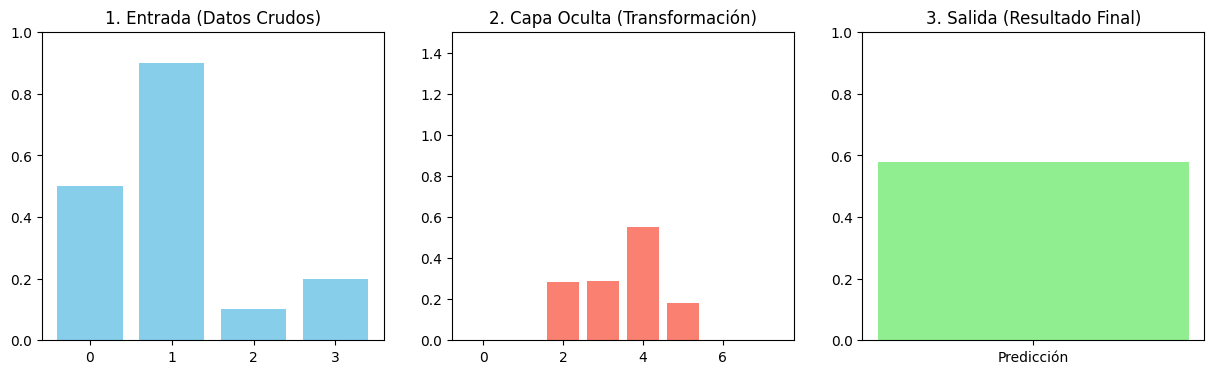

La red predice un valor de: 0.5787


In [4]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# 1. Definimos el modelo de forma explícita
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(4,), name="Entrada"),
    tf.keras.layers.Dense(8, activation='relu', name="Capa_Oculta"),
    tf.keras.layers.Dense(1, activation='sigmoid', name="Salida")
])

# IMPORTANTE: "Llamamos" al modelo con datos ficticios para que se construya internamente
# Esto evita el error de "layer has never been called"
dummy_input = tf.ones((1, 4))
model(dummy_input)

# 2. Simulamos un dato real viajando por la red
# Supongamos: [Horas sueño, Horas estudio, Café tomado, Nivel estrés]
dato_alumno = np.array([[0.5, 0.9, 0.1, 0.2]], dtype=np.float32)

# 3. Obtenemos las activaciones manualmente
activacion_oculta = model.layers[0](dato_alumno).numpy()
activacion_salida = model.layers[1](activacion_oculta).numpy()

# 4. Graficamos el flujo
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

ax[0].bar(range(4), dato_alumno[0], color='skyblue')
ax[0].set_title("1. Entrada (Datos Crudos)")
ax[0].set_ylim(0, 1)

ax[1].bar(range(8), activacion_oculta[0], color='salmon')
ax[1].set_title("2. Capa Oculta (Transformación)")
ax[1].set_ylim(0, 1.5)

ax[2].bar(["Predicción"], activacion_salida[0], color='lightgreen')
ax[2].set_title("3. Salida (Resultado Final)")
ax[2].set_ylim(0, 1)

plt.show()
print(f"La red predice un valor de: {activacion_salida[0][0]:.4f}")


In [5]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Definir la estructura de la red
model = models.Sequential([
    # Capa de entrada y primera capa oculta (16 neuronas, activación ReLU)
    layers.Dense(16, activation='relu', input_shape=(8,)),

    # Segunda capa oculta (8 neuronas, activación ReLU)
    layers.Dense(8, activation='relu'),

    # Capa de salida (1 neurona, activación Sigmoide para clasificación binaria)
    layers.Dense(1, activation='sigmoid')
])

# Compilación: Aquí definimos el OPTIMIZADOR
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 289 (1.13 KB)

 Trainable params: 289 (1.13 KB)

 Non-trainable params: 0 (0.00 B)

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


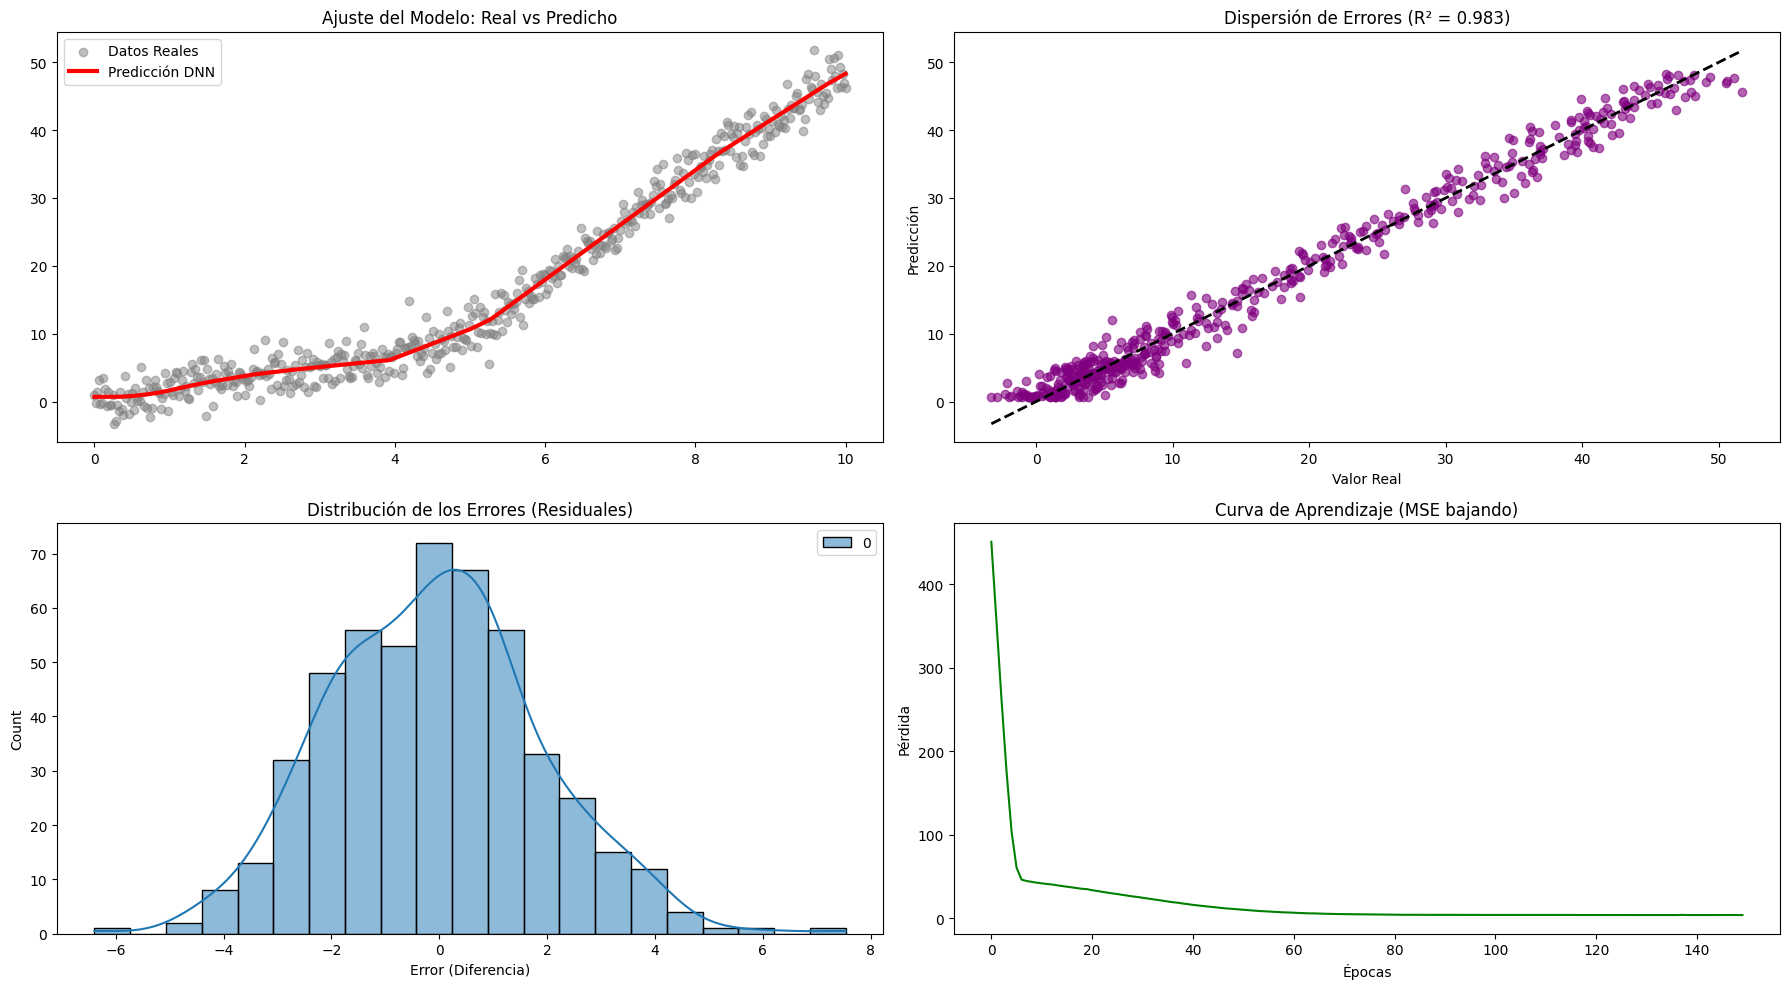


--- RESUMEN DE RENDIMIENTO ---
                     Métrica    Valor
  MAE (Error Medio Absoluto) 1.552991
MSE (Error Cuadrático Medio) 3.823002
         RMSE (Raíz del MSE) 1.955250
    R² (Coef. Determinación) 0.983406


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras import layers, models

# 1. GENERACIÓN DE DATOS (Relación no lineal para que la red trabaje)
np.random.seed(42)
X = np.linspace(0, 10, 500).reshape(-1, 1)
y = 2 * np.sin(X) + (0.5 * X**2) + np.random.normal(0, 2, X.shape) # Curva con ruido

# 2. ARQUITECTURA DNN (Deep Neural Network)
model = models.Sequential([
    layers.Input(shape=(1,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1) # Sin activación al final para Regresión
])

model.compile(optimizer='adam', loss='mse')

# 3. ENTRENAMIENTO
history = model.fit(X, y, epochs=150, verbose=0)
y_pred = model.predict(X)

# 4. CÁLCULO DE MÉTRICAS (Punto clave de tu clase)
mae = mean_absolute_error(y, y_pred)
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y, y_pred)

# --- PANEL DE VISUALIZACIÓN ---
plt.figure(figsize=(18, 10))

# Gráfica 1: Real vs Predicho (Ajuste de la curva)
plt.subplot(2, 2, 1)
plt.scatter(X, y, color='gray', alpha=0.5, label='Datos Reales')
plt.plot(X, y_pred, color='red', lw=3, label='Predicción DNN')
plt.title("Ajuste del Modelo: Real vs Predicho")
plt.legend()

# Gráfica 2: Dispersión (Idealmente una línea diagonal)
plt.subplot(2, 2, 2)
plt.scatter(y, y_pred, alpha=0.6, color='purple')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
plt.xlabel('Valor Real')
plt.ylabel('Predicción')
plt.title(f"Dispersión de Errores (R² = {r2:.3f})")

# Gráfica 3: Distribución del Error (Residuales)
plt.subplot(2, 2, 3)
error = y - y_pred
sns.histplot(error, kde=True, color='orange')
plt.title("Distribución de los Errores (Residuales)")
plt.xlabel("Error (Diferencia)")

# Gráfica 4: Evolución del Entrenamiento (Loss)
plt.subplot(2, 2, 4)
plt.plot(history.history['loss'], color='green')
plt.title("Curva de Aprendizaje (MSE bajando)")
plt.xlabel("Épocas")
plt.ylabel("Pérdida")

plt.tight_layout()
plt.show()

# TABLA DE MÉTRICAS
metrics_df = pd.DataFrame({
    "Métrica": ["MAE (Error Medio Absoluto)", "MSE (Error Cuadrático Medio)", "RMSE (Raíz del MSE)", "R² (Coef. Determinación)"],
    "Valor": [mae, mse, rmse, r2]
})
print("\n--- RESUMEN DE RENDIMIENTO ---")
print(metrics_df.to_string(index=False))


Entrenando la red con datos reales...
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


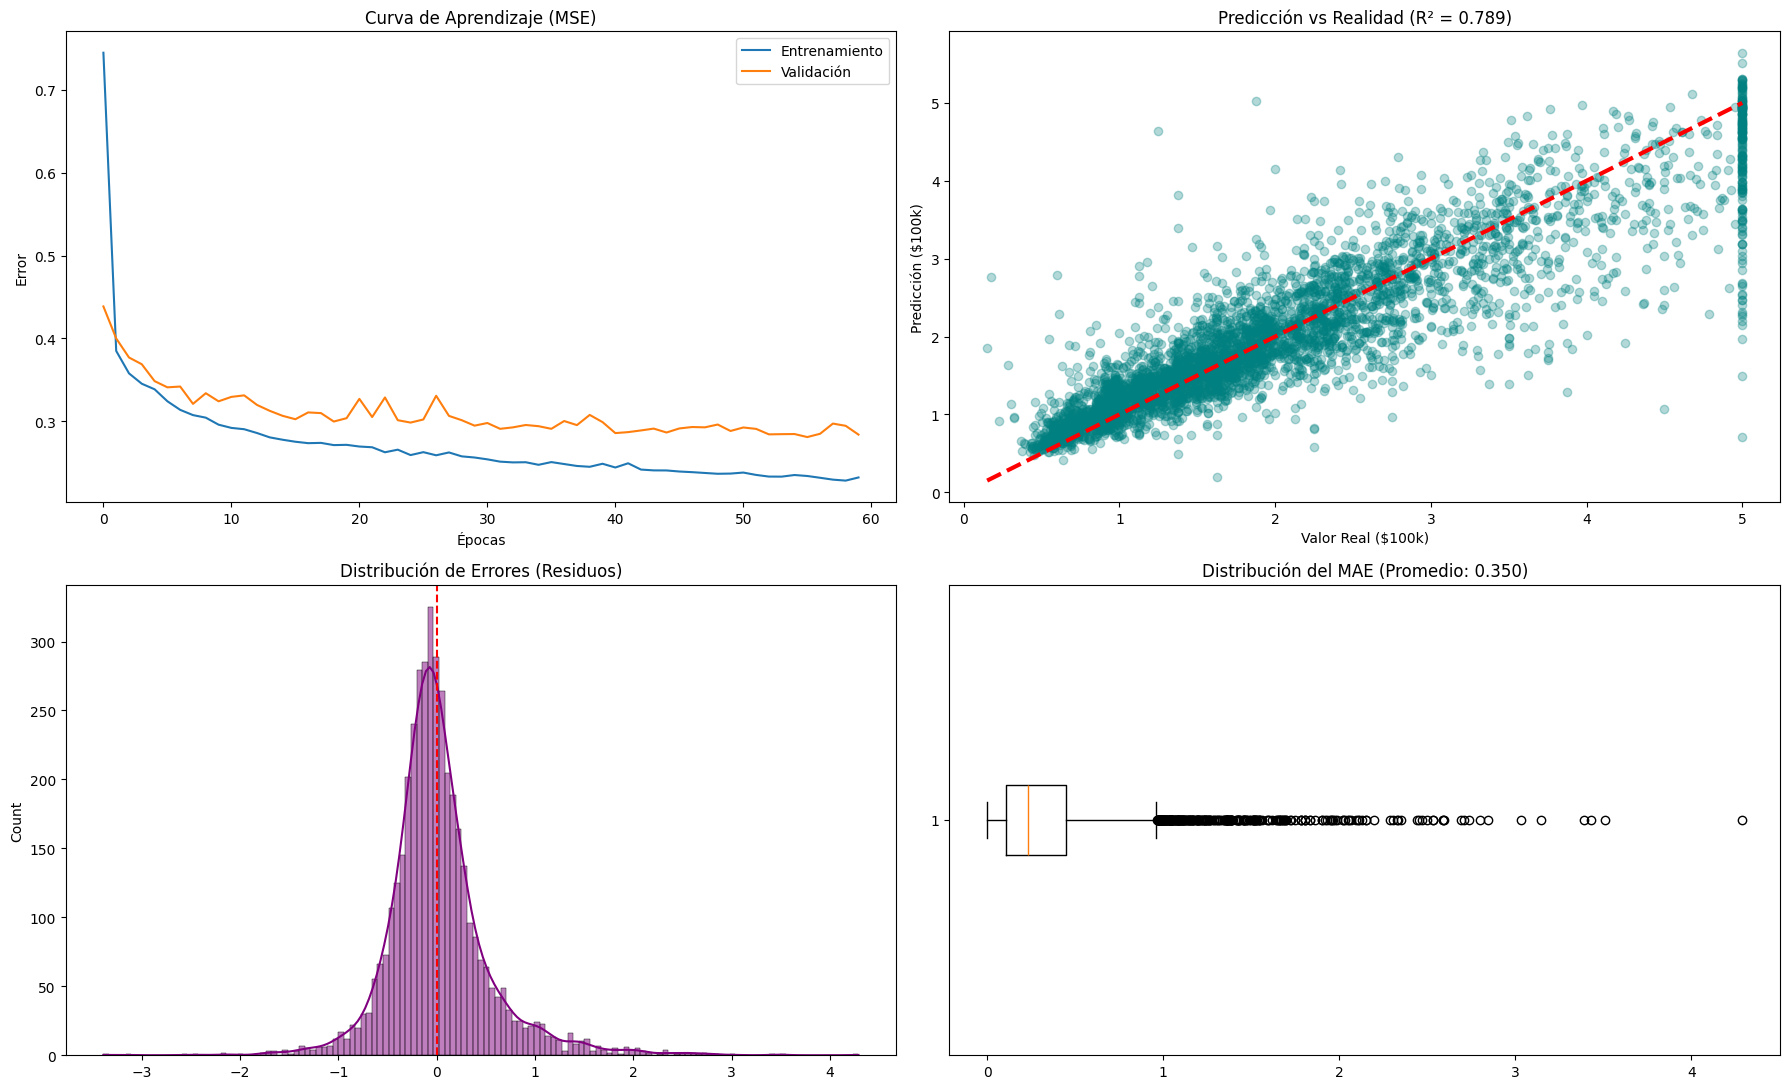


--- RENDIMIENTO FINAL ---
R² (Precisión): 0.7888
MAE (Error promedio): 0.3501 (~$35011 USD)
RMSE (Sensibilidad a errores grandes): 0.5260


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras import layers, models

# 1. CARGA Y PREPARACIÓN DE DATOS REALES
data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
X = df.values
y = data.target # Precio en unidades de $100,000

# Dividir y Escalar (Fundamental para Redes Neuronales)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 2. ARQUITECTURA DNN PROFUNDA
model = models.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(1) # Salida lineal para regresión
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# 3. ENTRENAMIENTO
print("Entrenando la red con datos reales...")
history = model.fit(X_train, y_train, epochs=60, batch_size=32, validation_split=0.2, verbose=0)

# 4. PREDICCIÓN Y MÉTRICAS
y_pred = model.predict(X_test).flatten()
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

# --- PANEL DE DIAGNÓSTICO VISUAL ---
plt.figure(figsize=(18, 11))

# Gráfica A: Pérdida vs Épocas (Evolución del Optimizador)
plt.subplot(2, 2, 1)
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.title("Curva de Aprendizaje (MSE)")
plt.xlabel("Épocas"); plt.ylabel("Error"); plt.legend()

# Gráfica B: Predicho vs Real (Línea de Identidad)
plt.subplot(2, 2, 2)
plt.scatter(y_test, y_pred, alpha=0.3, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=3)
plt.title(f"Predicción vs Realidad (R² = {r2:.3f})")
plt.xlabel("Valor Real ($100k)"); plt.ylabel("Predicción ($100k)")

# Gráfica C: Distribución de Errores (Residuos)
plt.subplot(2, 2, 3)
residuos = y_test - y_pred
sns.histplot(residuos, kde=True, color='purple')
plt.axvline(0, color='red', linestyle='--')
plt.title("Distribución de Errores (Residuos)")

# Gráfica D: Error Absoluto por Muestra
plt.subplot(2, 2, 4)
plt.boxplot(np.abs(residuos), vert=False)
plt.title(f"Distribución del MAE (Promedio: {mae:.3f})")

plt.tight_layout()
plt.show()

# Tabla de Resultados Finales
print(f"\n--- RENDIMIENTO FINAL ---")
print(f"R² (Precisión): {r2:.4f}")
print(f"MAE (Error promedio): {mae:.4f} (~${mae*100000:.0f} USD)")
print(f"RMSE (Sensibilidad a errores grandes): {rmse:.4f}")
